# Dipendenti pubblici 2021-2023 - preanalysis v1

## Domanda principale

Come sta cambiando il pubblico impiego tra il 2021 e il 2023, e in quali comparti si concentra la dinamica?

## Perché conta

Questo primo output prova a rispondere a una domanda semplice ma importante: la crescita recente del pubblico impiego è diffusa oppure è trainata soprattutto da pochi comparti?

La tesi di partenza è questa:

- tra 2021 e 2023 il pubblico impiego torna a crescere
- il saldo tra assunti e cessati migliora nettamente
- la crescita non è uniforme: pesa soprattutto l'espansione di **Istruzione e ricerca** e **Sanità**

In questa fase il perimetro resta volutamente stretto:
- solo `2021-2023`
- solo lettura per comparto
- niente ranking ente per ente


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

PROJECT_DIR = Path.cwd().parent
REPO_ROOT = PROJECT_DIR.parents[2]
OUT_DIR = REPO_ROOT / 'out' / 'data' / 'mart' / 'dipendenti_pubblici_2021_2023'

frames = []
for year in [2021, 2022, 2023]:
    path = OUT_DIR / str(year) / 'mart_comparti_anno.parquet'
    df = pd.read_parquet(path)
    frames.append(df)

mart = pd.concat(frames, ignore_index=True)
mart.head()


,anno,comparto,dipendenti_totali,assunti_totali,cessati_totali,saldo_netto,tasso_assunzione_pct,tasso_uscita_pct,tasso_turnover_lordo_pct,quota_donne_pct
0,2021,ISTRUZIONE E RICERCA,1264060.0,57043.0,56287.0,756.0,4.51,4.45,8.97,77.36
1,2021,SANITA',670637.0,60312.0,54080.0,6232.0,8.99,8.06,17.06,68.73
2,2021,PERSONALE IN REGIME DI DIRITTO PUBBLICO,568103.0,20605.0,23066.0,-2461.0,3.63,4.06,7.69,12.29
3,2021,FUNZIONI LOCALI,493268.0,49072.0,46791.0,2281.0,9.95,9.49,19.43,56.23
4,2021,FUNZIONI CENTRALI,203876.0,8171.0,18975.0,-10804.0,4.01,9.31,13.31,54.36


In [2]:
totali = (
    mart.groupby('anno', as_index=False)[['dipendenti_totali', 'assunti_totali', 'cessati_totali', 'saldo_netto']]
    .sum()
)
totali


,anno,dipendenti_totali,assunti_totali,cessati_totali,saldo_netto
0,2021,3240397.0,197844.0,206422.0,-8578.0
1,2022,3271447.0,214649.0,207336.0,7313.0
2,2023,3327854.0,248606.0,192640.0,55966.0


In [3]:
display(Markdown(
    f"""
## Tre numeri chiave

- dipendenti totali: **{int(totali.loc[totali['anno'] == 2021, 'dipendenti_totali'].iloc[0]):,}** nel 2021 -> **{int(totali.loc[totali['anno'] == 2023, 'dipendenti_totali'].iloc[0]):,}** nel 2023
- saldo netto: **{int(totali.loc[totali['anno'] == 2021, 'saldo_netto'].iloc[0]):,}** nel 2021 -> **{int(totali.loc[totali['anno'] == 2023, 'saldo_netto'].iloc[0]):,}** nel 2023
- assunti totali: **{int(totali.loc[totali['anno'] == 2023, 'assunti_totali'].iloc[0]):,}** nel 2023
""".replace(',', '.')
))



## Tre numeri chiave

- dipendenti totali: **3.240.397** nel 2021 -> **3.327.854** nel 2023
- saldo netto: **-8.578** nel 2021 -> **55.966** nel 2023
- assunti totali: **248.606** nel 2023


In [4]:
delta_comparti = (
    mart.pivot(index='comparto', columns='anno', values='dipendenti_totali')
    .fillna(0)
    .reset_index()
)
delta_comparti['delta_2023_vs_2021'] = delta_comparti[2023] - delta_comparti[2021]
delta_comparti.sort_values('delta_2023_vs_2021', ascending=False)


anno,comparto,2021,2022,2023,delta_2023_vs_2021
3,ISTRUZIONE E RICERCA,1264060.0,1281716.0,1306941.0,42881.0
5,SANITA',670637.0,681852.0,701170.0,30533.0
4,PERSONALE IN REGIME DI DIRITTO PUBBLICO,568103.0,576257.0,579322.0,11219.0
1,FUNZIONI CENTRALI,203876.0,198050.0,205204.0,1328.0
0,COMPARTO AUTONOMO O FUORI COMPARTO,40453.0,41047.0,41250.0,797.0
2,FUNZIONI LOCALI,493268.0,492525.0,493967.0,699.0


## Andamento generale

Il primo segnale da verificare è se il triennio mostri davvero un'inversione rispetto al 2021. Qui guardiamo insieme stock totale e saldo netto.


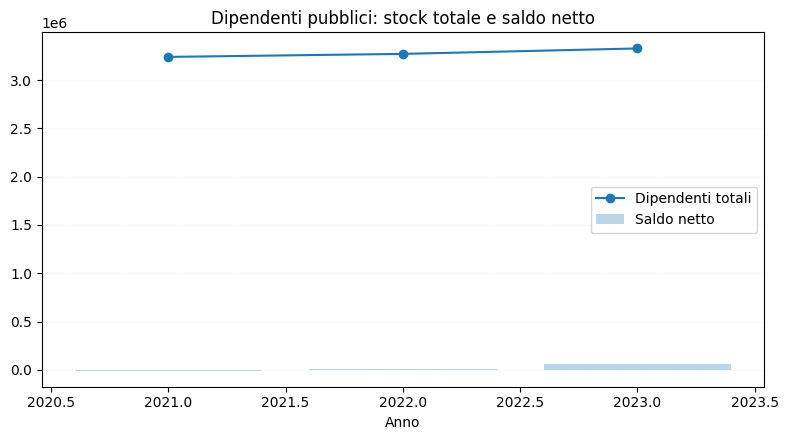

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(totali['anno'], totali['dipendenti_totali'], marker='o', label='Dipendenti totali')
ax.bar(totali['anno'], totali['saldo_netto'], alpha=0.3, label='Saldo netto')
ax.set_title('Dipendenti pubblici: stock totale e saldo netto')
ax.set_xlabel('Anno')
ax.grid(axis='y', alpha=0.2, linestyle=':')
ax.legend()
plt.tight_layout()
plt.show()


## Dove si concentra la crescita

Se il totale cresce, il punto successivo è capire se la crescita è diffusa o se è trainata soprattutto da pochi comparti.


C:\Users\gabry\AppData\Local\Temp\ipykernel_26324\3075055336.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_delta['comparto'], rotation=30, ha='right')


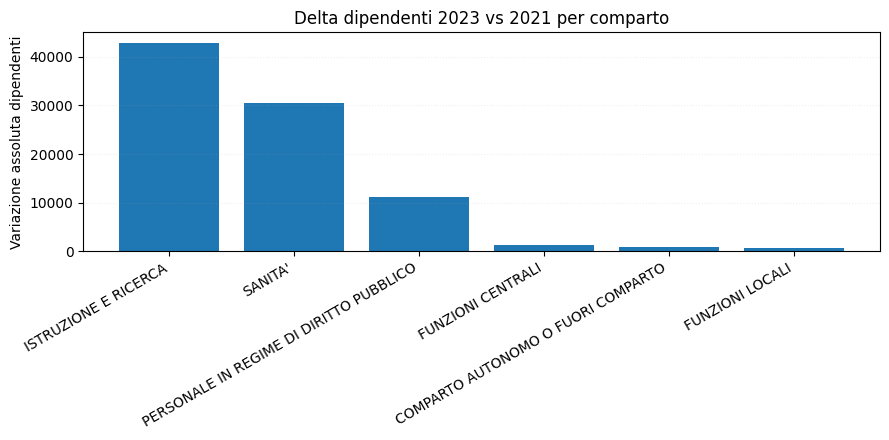

In [6]:
plot_delta = delta_comparti.sort_values('delta_2023_vs_2021', ascending=False).copy()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(plot_delta['comparto'], plot_delta['delta_2023_vs_2021'])
ax.set_title('Delta dipendenti 2023 vs 2021 per comparto')
ax.set_ylabel('Variazione assoluta dipendenti')
ax.set_xticklabels(plot_delta['comparto'], rotation=30, ha='right')
ax.grid(axis='y', alpha=0.2, linestyle=':')
plt.tight_layout()
plt.show()


## Turnover e composizione nel 2023

Come lettura finale, guardiamo il 2023: tassi di assunzione e uscita, saldo netto e quota donne per comparto. Non è ancora una storia autonoma, ma aiuta a leggere meglio la struttura della crescita.


In [7]:
top_2023 = mart[mart['anno'] == 2023].sort_values('dipendenti_totali', ascending=False).copy()
top_2023[['comparto', 'dipendenti_totali', 'assunti_totali', 'cessati_totali', 'saldo_netto', 'quota_donne_pct']]


,comparto,dipendenti_totali,assunti_totali,cessati_totali,saldo_netto,quota_donne_pct
12,ISTRUZIONE E RICERCA,1306941.0,59639.0,38802.0,20837.0,77.22
13,SANITA',701170.0,90861.0,68738.0,22123.0,69.33
14,PERSONALE IN REGIME DI DIRITTO PUBBLICO,579322.0,30815.0,27728.0,3087.0,13.73
15,FUNZIONI LOCALI,493967.0,44533.0,41458.0,3075.0,57.26
16,FUNZIONI CENTRALI,205204.0,20541.0,13658.0,6883.0,54.45
17,COMPARTO AUTONOMO O FUORI COMPARTO,41250.0,2217.0,2256.0,-39.0,46.26


In [8]:
turnover_2023 = top_2023[['comparto', 'tasso_assunzione_pct', 'tasso_uscita_pct', 'tasso_turnover_lordo_pct', 'saldo_netto', 'quota_donne_pct']].copy()
turnover_2023


,comparto,tasso_assunzione_pct,tasso_uscita_pct,tasso_turnover_lordo_pct,saldo_netto,quota_donne_pct
12,ISTRUZIONE E RICERCA,4.56,2.97,NaN,20837.0,77.22
13,SANITA',12.96,9.80,NaN,22123.0,69.33
14,PERSONALE IN REGIME DI DIRITTO PUBBLICO,5.32,4.79,NaN,3087.0,13.73
15,FUNZIONI LOCALI,9.02,8.39,NaN,3075.0,57.26
16,FUNZIONI CENTRALI,10.01,6.66,NaN,6883.0,54.45
17,COMPARTO AUTONOMO O FUORI COMPARTO,5.37,5.47,NaN,-39.0,46.26


In [9]:
display(Markdown(
    f"""
## Prime evidenze

- i dipendenti totali passano da **{int(totali.loc[totali['anno'] == 2021, 'dipendenti_totali'].iloc[0]):,}** a **{int(totali.loc[totali['anno'] == 2023, 'dipendenti_totali'].iloc[0]):,}**
- il saldo netto totale passa da **{int(totali.loc[totali['anno'] == 2021, 'saldo_netto'].iloc[0]):,}** nel 2021 a **{int(totali.loc[totali['anno'] == 2023, 'saldo_netto'].iloc[0]):,}** nel 2023
- i comparti con la crescita assoluta piu forte tra 2021 e 2023 sono **Istruzione e ricerca** e **Sanita'**
- nel 2023 **Funzioni centrali** mostra un miglioramento netto del saldo rispetto al 2021
- la composizione di genere resta molto diversa tra comparti: **Istruzione e ricerca** e **Sanita'** hanno quote femminili molto piu alte del comparto in regime di diritto pubblico
""".replace(',', '.')
))



## Prime evidenze

- i dipendenti totali passano da **3.240.397** a **3.327.854**
- il saldo netto totale passa da **-8.578** nel 2021 a **55.966** nel 2023
- i comparti con la crescita assoluta piu forte tra 2021 e 2023 sono **Istruzione e ricerca** e **Sanita'**
- nel 2023 **Funzioni centrali** mostra un miglioramento netto del saldo rispetto al 2021
- la composizione di genere resta molto diversa tra comparti: **Istruzione e ricerca** e **Sanita'** hanno quote femminili molto piu alte del comparto in regime di diritto pubblico


## Nota metodologica minima

- questo primo output lavora solo sui **comparti**, non sui singoli enti
- il triennio `2021-2023` basta per una prima lettura, ma non ancora per una storia lunga del pubblico impiego
- la lettura e descrittiva: mostra dove si concentra la crescita, non spiega da sola perché avvenga
